In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
from parse_levels import process_metrics, human_train_time_dict, convert_to_dict, compute_gap_in_percentage
from parse_levels import filter_folder_info
import pandas as pd
import matplotlib.ticker as ticker
from plot_utils import plot_gap_comparison
import re
import copy
import json

In [2]:
# for each item in the dict, if any two have the same 'record', remove the one with lower number of steps in metric
def deduplicate_metrics(search_results):
    records_length_so_far = {}
    new_search_results = {}
    for key, value in search_results.items():
        if value['record'] not in records_length_so_far:
            records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
            new_search_results[key] = value
        else:
            if len(value['metrics']['step']) > records_length_so_far[value['record']][0]:
                new_search_results.pop(records_length_so_far[value['record']][1])

                records_length_so_far[value['record']] = (len(value['metrics']['step']), key)
                new_search_results[key] = value
    return new_search_results



In [3]:
# ori_results = find_levels_in_configs_glob(
#     [
#         '/checkpoint/maui/zhaobc/scientist/workspace/record_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250424_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250425_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
#         #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
#         # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
#     ]
# )
with open('results.cache', 'r') as f:
    ori_results = json.load(f)

In [4]:
folder_info = ori_results

In [5]:
len(folder_info)

888

In [ ]:
# flat search -- n_initial_hypotheses = 50
flat_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 50),
]
# tree search -- n_initial_hypotheses = 1, n_hypotheses = 3
tree_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 1),
    ('n_hypotheses', 3),
]
# forest search -- n_initial_hypotheses = 3, n_hypotheses = 3
forest_params = [
    ('runner', 'bon'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
]
# AIDE -- n_initial_hypotheses = 3, n_hypotheses = 1, debug_prob = 0.5
aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 1),
    ('debug_prob', 0.5),
]
# MultiAIDE -- n_initial_hypotheses = 3, n_hypotheses = 3, debug_prob = 0.5
multi_aide_params = [
    ('runner', 'aide'),
    ('n_initial_hypotheses', 3),
    ('n_hypotheses', 3),
    ('debug_prob', 0.5),
]
# for each search algo, we get the R1 and O3 with level 1, 12, 125 results for plotting
# thats 6 results for each search algo, so we plot with 3 columns (level) and 2 rows (R1 and O3)

search_algo_params = {
    'flat': flat_params,
    'tree': tree_params,
    'forest': forest_params,
    'aide': aide_params,
    'multi_aide': multi_aide_params,
}

plot_info = {}

for search_algo, params in search_algo_params.items():
    plot_info[search_algo] = {}
    for level in [1, 12, 125]:
        plot_info[search_algo][level] = {}
        for model in ['deepseek-r1', 'o3-mini']:
            search_params = params + [('levels', level), ('model', model)]
            filtered_folder_info = filter_folder_info(folder_info, search_params)
            print(f'{search_algo} {level} {model} {len(filtered_folder_info)}')
            plot_info[search_algo][level][model] = filtered_folder_info



flat 1 deepseek-r1 18
flat 1 o3-mini 18
flat 12 deepseek-r1 18
flat 12 o3-mini 18
flat 125 deepseek-r1 18
flat 125 o3-mini 18
tree 1 deepseek-r1 18
tree 1 o3-mini 18
tree 12 deepseek-r1 18
tree 12 o3-mini 18
tree 125 deepseek-r1 18
tree 125 o3-mini 18
forest 1 deepseek-r1 18
forest 1 o3-mini 18
forest 12 deepseek-r1 18
forest 12 o3-mini 18
forest 125 deepseek-r1 36
forest 125 o3-mini 36
aide 1 deepseek-r1 18
aide 1 o3-mini 18
aide 12 deepseek-r1 46
aide 12 o3-mini 36
aide 125 deepseek-r1 46
aide 125 o3-mini 46
multi_aide 1 deepseek-r1 18
multi_aide 1 o3-mini 18
multi_aide 12 deepseek-r1 18
multi_aide 12 o3-mini 18
multi_aide 125 deepseek-r1 34
multi_aide 125 o3-mini 26


In [7]:
figure_data = {}
for search_algo in search_algo_params.keys():
    for level in [1, 12, 125]:
        for model in ('deepseek-r1', 'o3-mini'):
            plot_info[search_algo][level][model] = process_metrics(plot_info[search_algo][level][model])
            plot_info[search_algo][level][model] = deduplicate_metrics(plot_info[search_algo][level][model])
            figure_data[f'{search_algo}_{level}_{model}'] = convert_to_dict(plot_info[search_algo][level][model])


In [8]:
plot_info['flat'][125]['o3-mini'].keys()

dict_keys(['record_4_20250424_065837_2088655-2088441-3', 'record_7_20250424_065837_2088791-2088441-6', 'record_15_20250424_065957_2089271-2088450-4', 'record_3_20250424_065837_2088654-2088441-2', 'record_11_20250424_065957_2089102-2088450-0', 'record_1_20250424_065837_2088652-2088441-0', 'record_13_20250424_065957_2089104-2088450-2', 'record_17_20250424_065957_2089273-2088450-6', 'record_8_20250424_065837_2088792-2088441-7', 'record_12_20250424_065957_2089103-2088450-1', 'record_14_20250424_065957_2089270-2088450-3', 'record_10_20250424_065837_2088441-2088441-9', 'record_16_20250424_065957_2089272-2088450-5', 'record_5_20250424_065837_2088789-2088441-4', 'record_18_20250424_065957_2088450-2088450-7', 'record_2_20250424_065837_2088653-2088441-1', 'record_6_20250424_065837_2088790-2088441-5', 'record_9_20250424_065837_2088793-2088441-8'])

In [9]:
'record_9_20250424_065837_2088793-2088441-8'

'record_9_20250424_065837_2088793-2088441-8'

In [10]:
metrics = plot_info['flat'][125]['o3-mini']['record_9_20250424_065837_2088793-2088441-8']['metrics']

In [11]:
metrics['train_time'].idxmin()

35

In [12]:
# Record	Train Time std
# 1	20183.68
# 2	18300.36
# 3	22270.99
# 4	37980.47
# 5	7365.53
# 6	5922.16
# 7	3805.14
# 8	9496.43
# 9	15747.18
# 10	2315.29
# 11	3259.97
# 12	1220.16
# 13	927.61
# 14	6034.27
# 15	2337.85
# 16	6700.25
# 17	40.5
# 18	1495.18
# 19	600.67
# 20	770.64
# 21	593.64
train_time_std = {
    1: 20183.68,
    2: 18300.36, 
    3: 22270.99,
    4: 37980.47,
    5: 7365.53,
    6: 5922.16,
    7: 3805.14,
    8: 9496.43,
    9: 15747.18,
    10: 2315.29,
    11: 3259.97,
    12: 1220.16,
    13: 927.61,
    14: 6034.27,
    15: 2337.85,
    16: 6700.25,
    17: 40.5,
    18: 1495.18,
    19: 600.67,
    20: 770.64,
    21: 593.64
}

In [13]:
human_train_time_dict

{1: 2968348,
 2: 2209926,
 3: 1386147,
 4: 1301740,
 5: 949528,
 6: 766259,
 7: 773072,
 8: 662205,
 9: 505531,
 10: 477150,
 11: 442985,
 12: 317839,
 13: 289805,
 14: 273107,
 15: 241463,
 16: 232971,
 17: 220374,
 18: 211840,
 19: 199442}

In [14]:

    gaps = {}
    for k, v in human_train_time_dict.items():
        if (k + 1) not in human_train_time_dict:
            continue
        gaps[k] = v - human_train_time_dict[k+1]

In [15]:
std_percentage = {}
for k, v in gaps.items():
    std_percentage[k] = train_time_std[k] / v
std_percentage


{1: 0.026612730115951277,
 2: 0.022215132942209014,
 3: 0.2638524056061701,
 4: 0.1078341169522901,
 5: 0.040189721120320404,
 6: -0.8692440921767209,
 7: 0.034321664697340055,
 8: 0.06061267344932791,
 9: 0.5548493710581023,
 10: 0.06776789111663983,
 11: 0.02604933437744714,
 12: 0.04352429193122637,
 13: 0.055552161935561145,
 14: 0.190692390342561,
 15: 0.27530028261893547,
 16: 0.5318925140906565,
 17: 0.004745722990391376,
 18: 0.12059848362639136}

In [16]:
for key in figure_data.keys():
    figure_data[key] = compute_gap_in_percentage(figure_data[key])
    figure_data[key] = {str(k): v for k, v in figure_data[key].items()}
    del figure_data[key]['6']

In [17]:
std_percentage = {str(k): v for k, v in std_percentage.items()}

In [18]:
# replace the ones with 300% improvement with 0 as they might be summarizer mistakes
for key in figure_data.keys():
    for k, v in figure_data[key].items():
        if v > 3 or v < 0:
            figure_data[key][k] = 0.

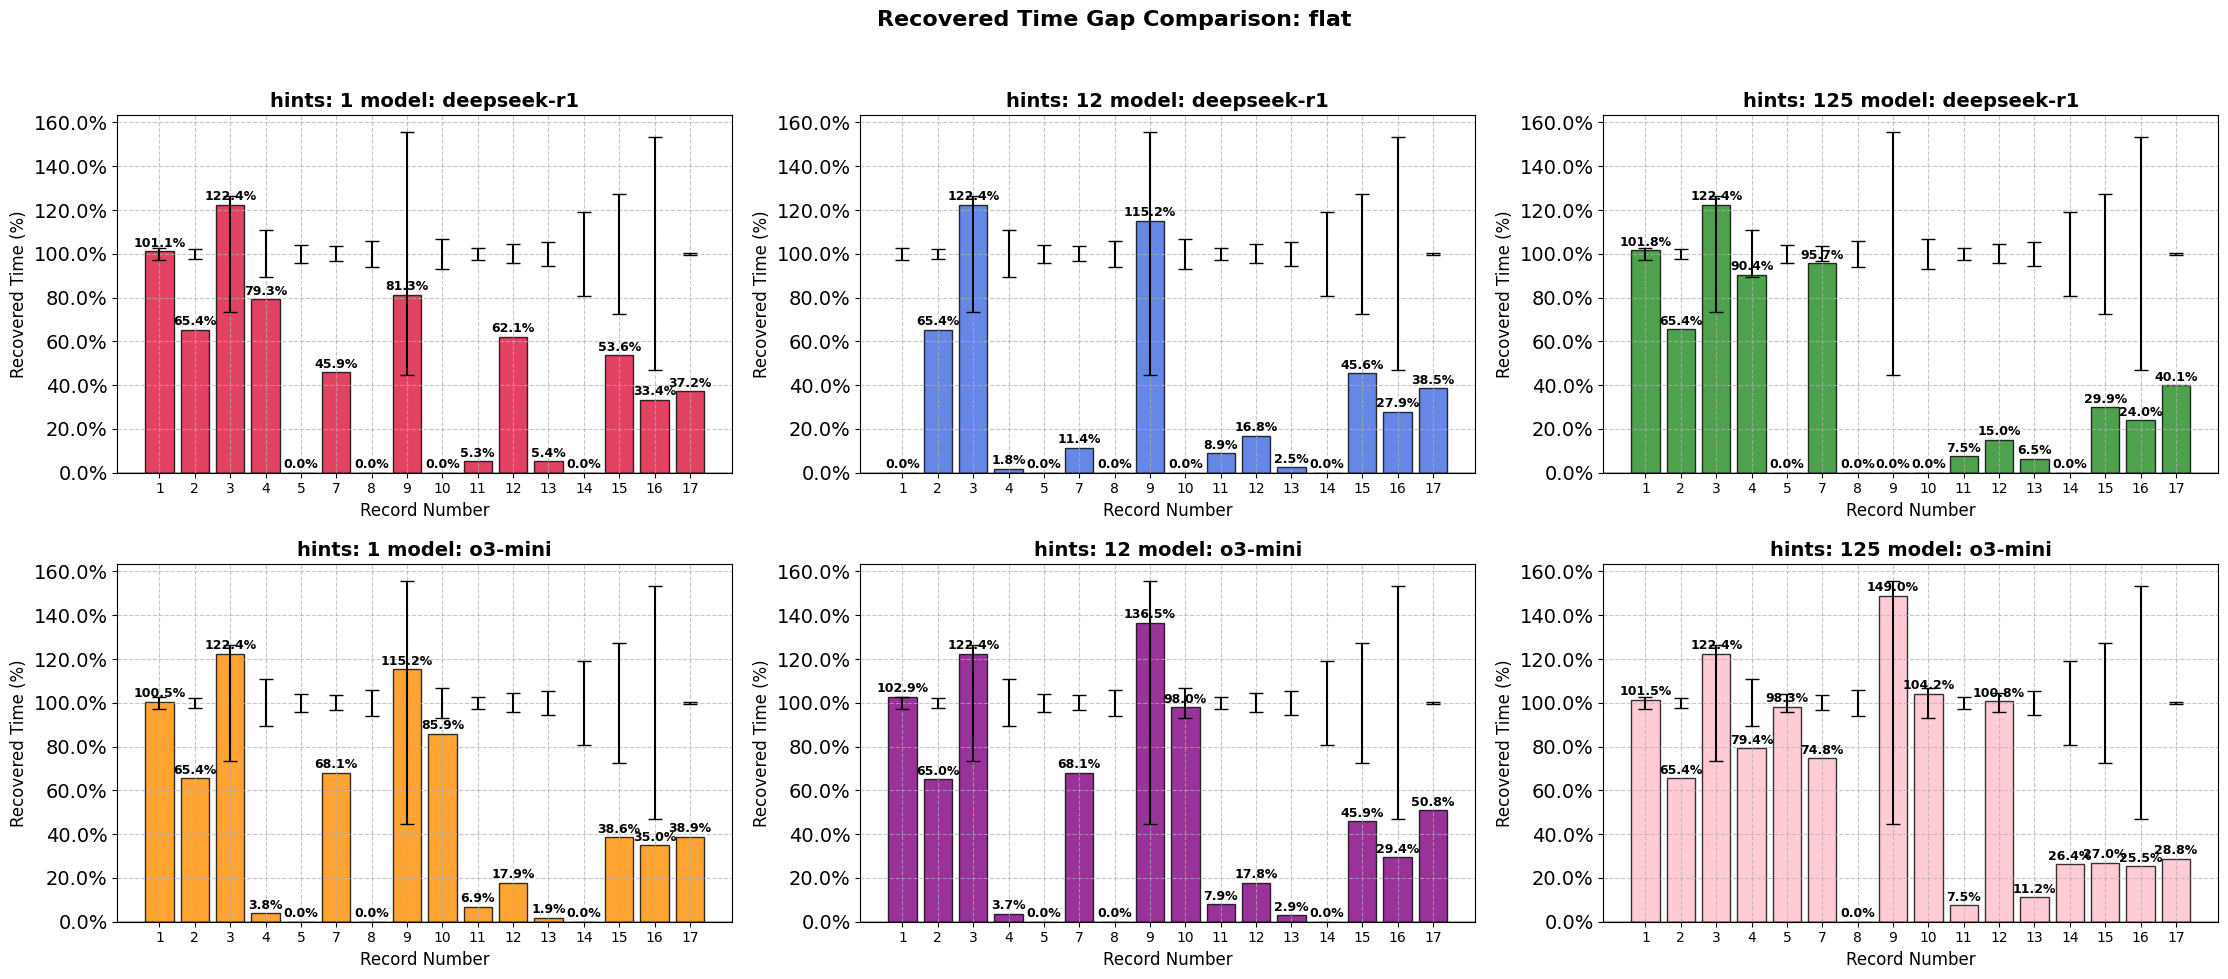

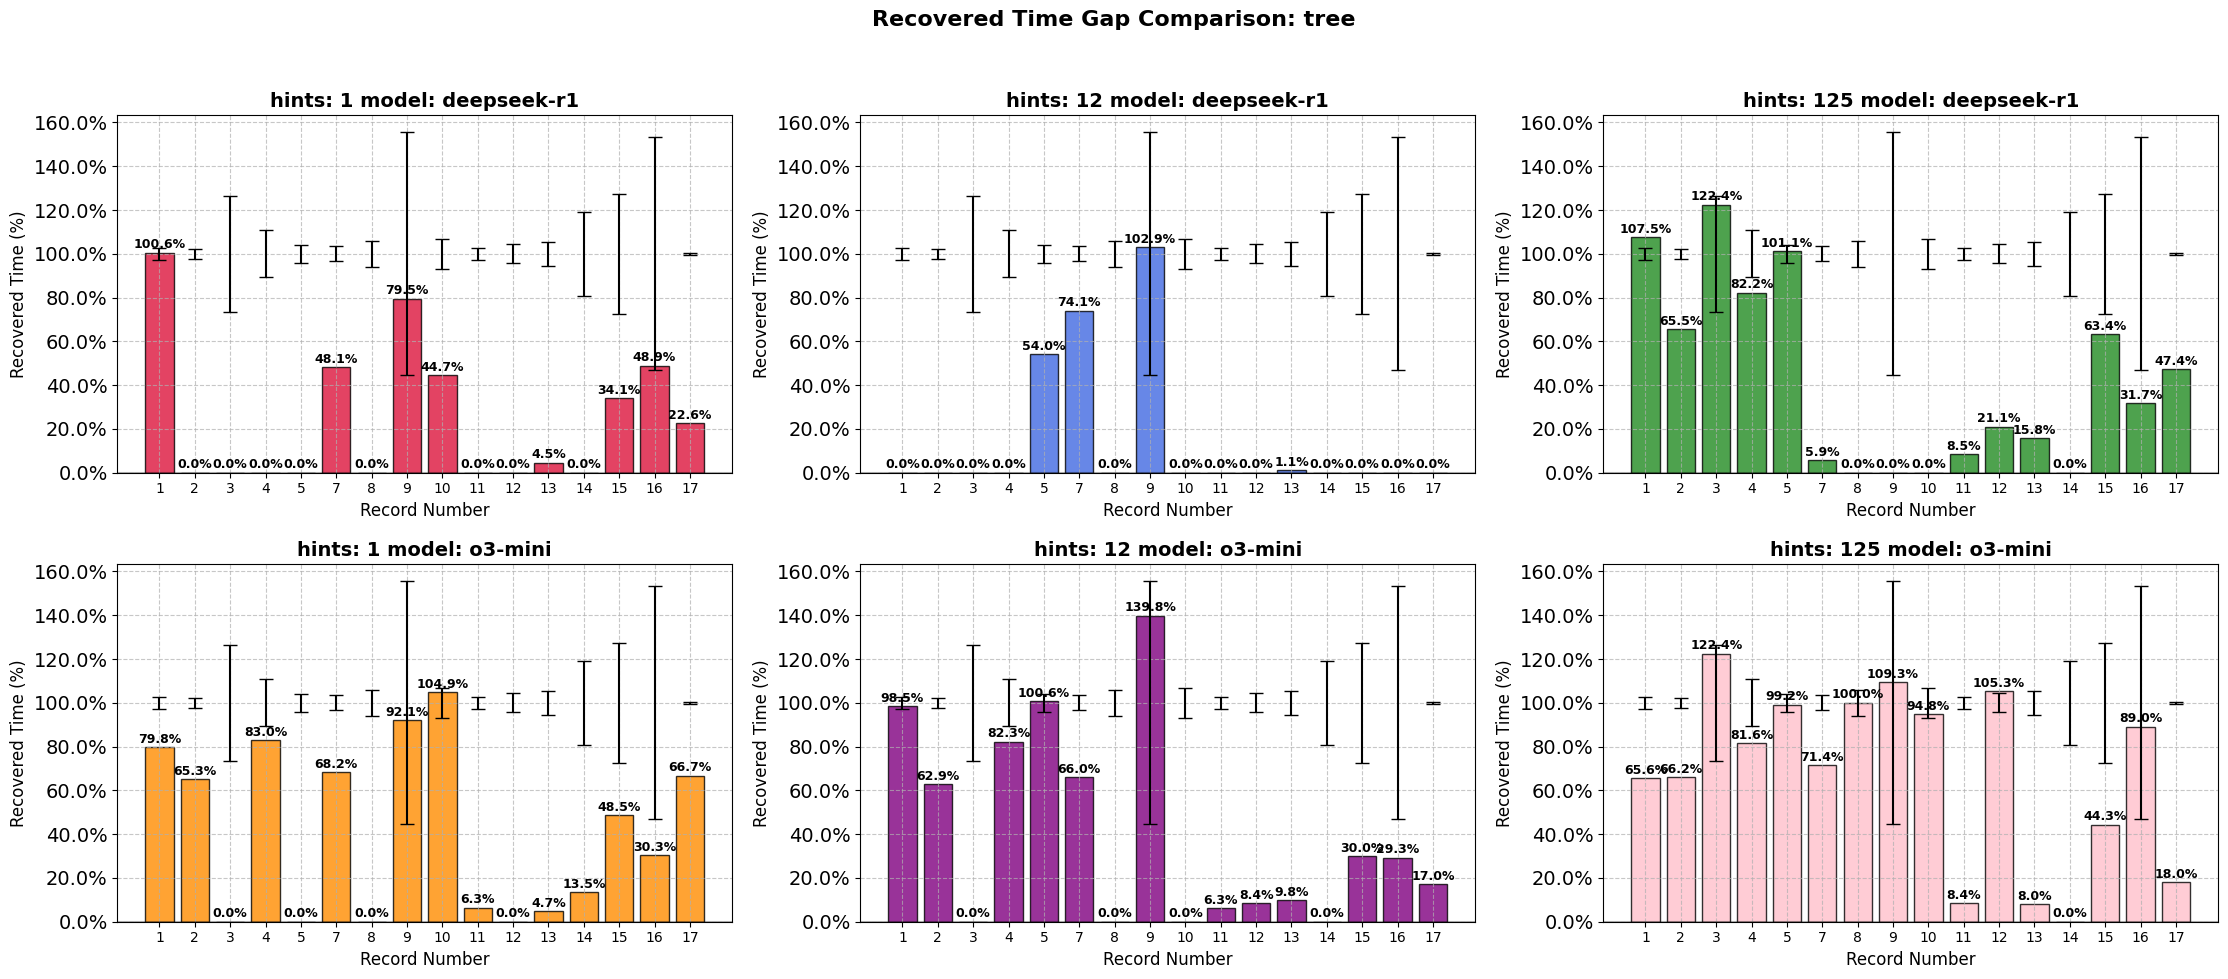

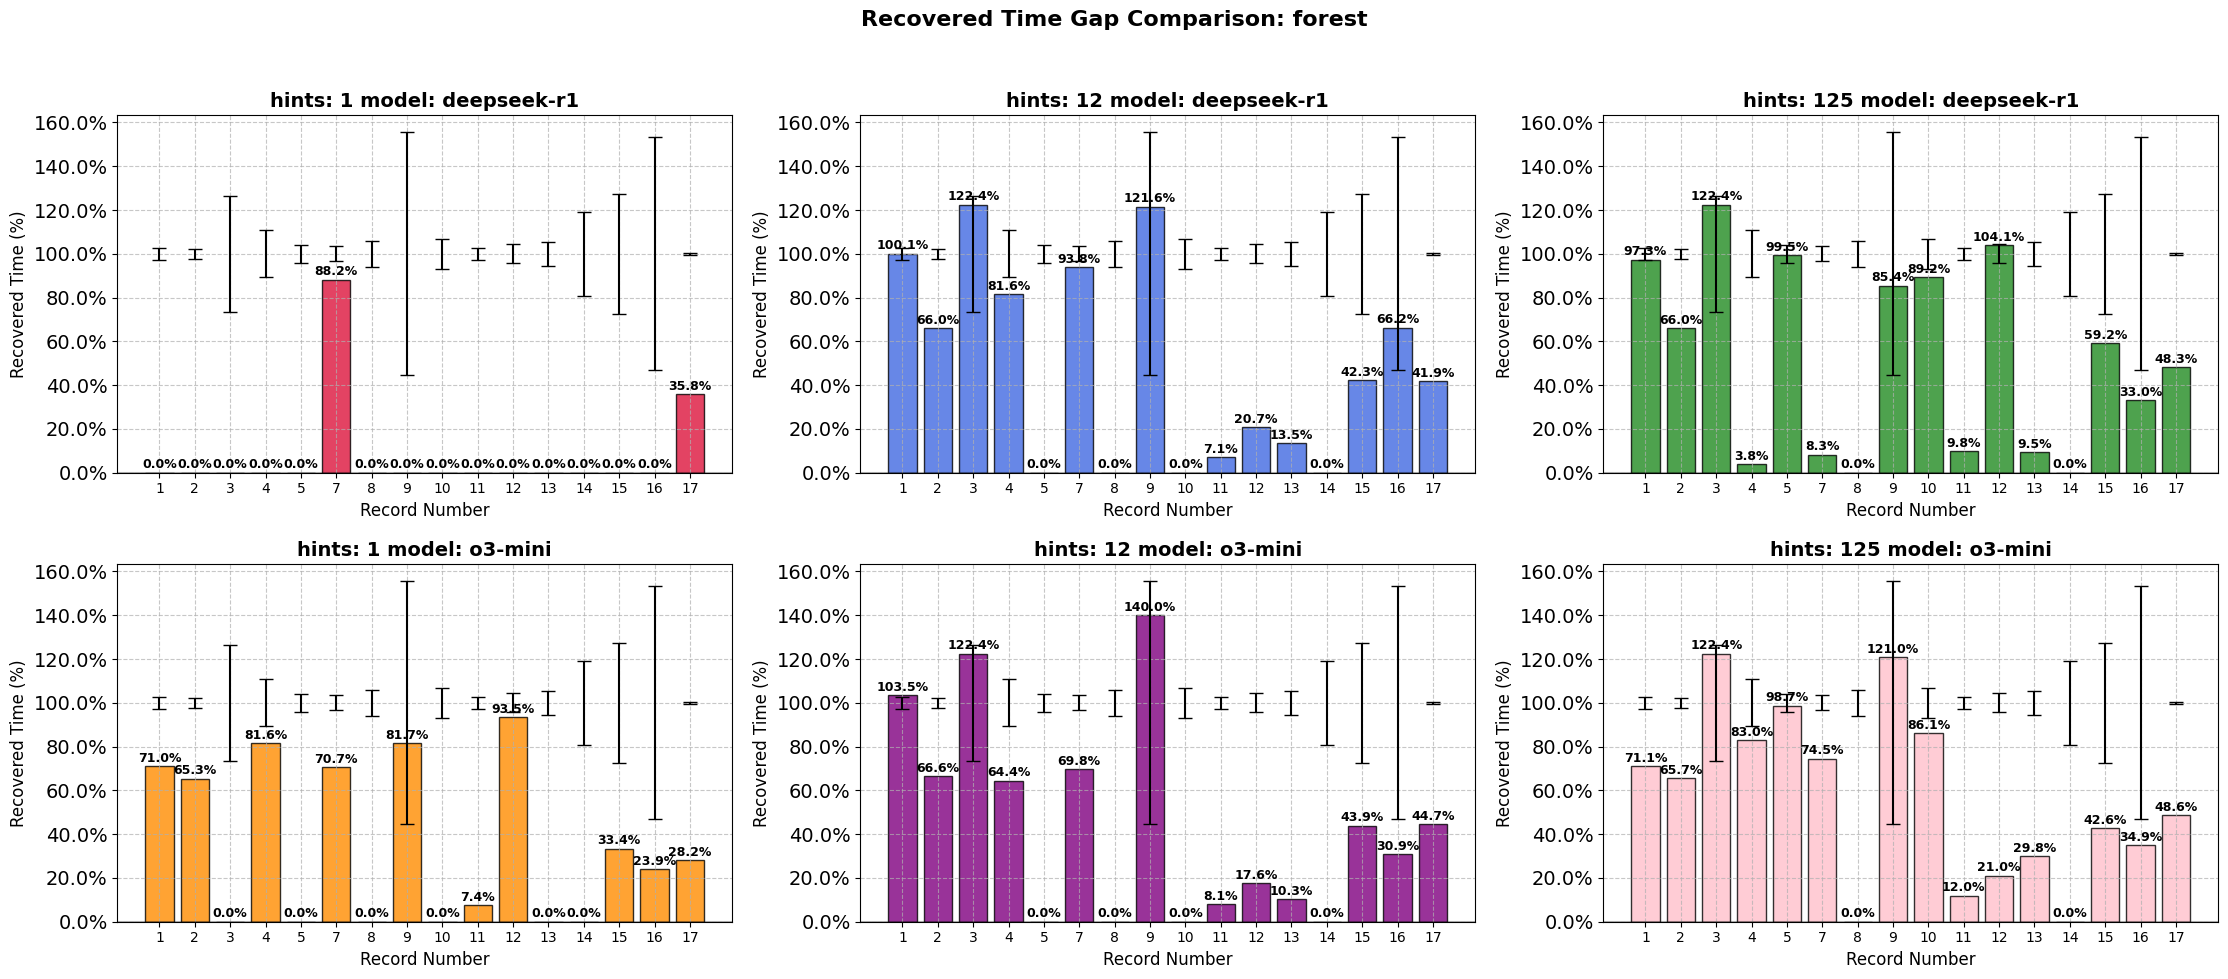

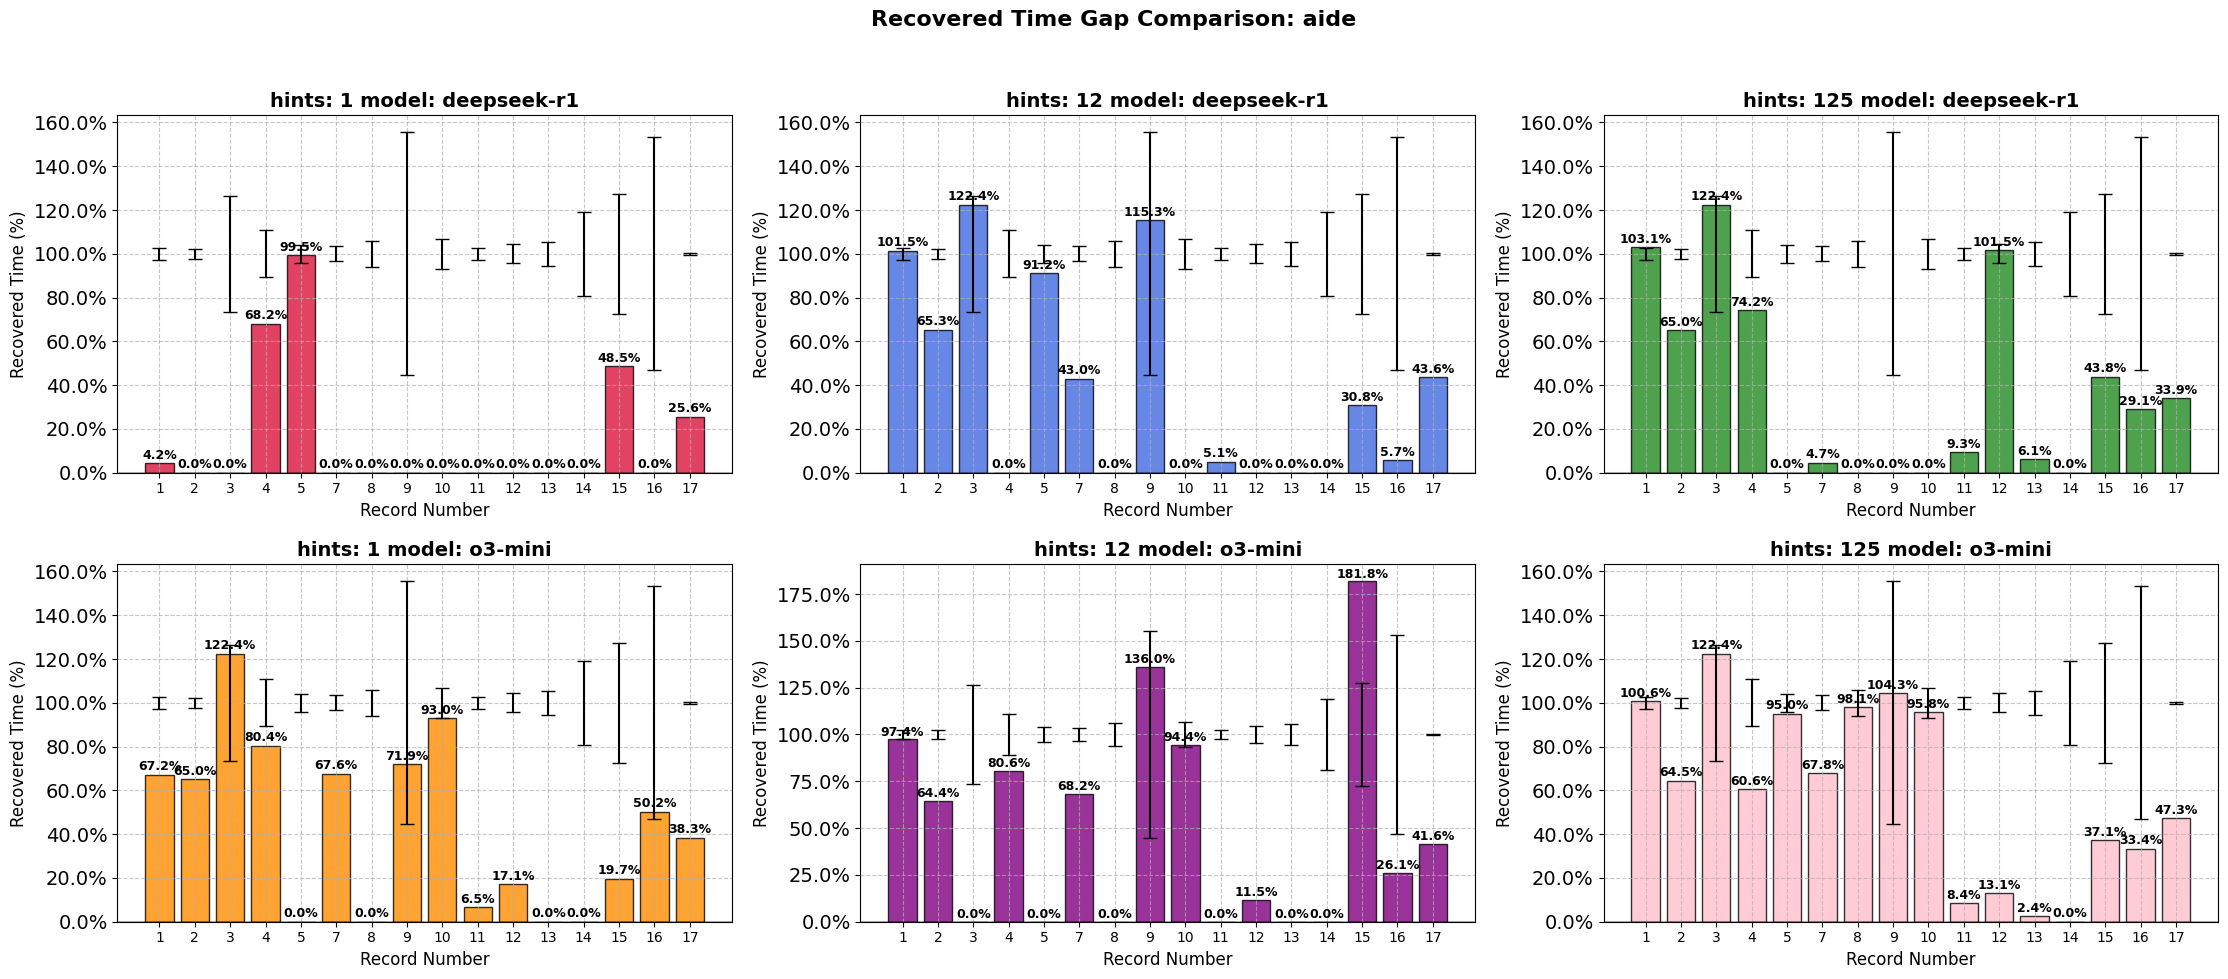

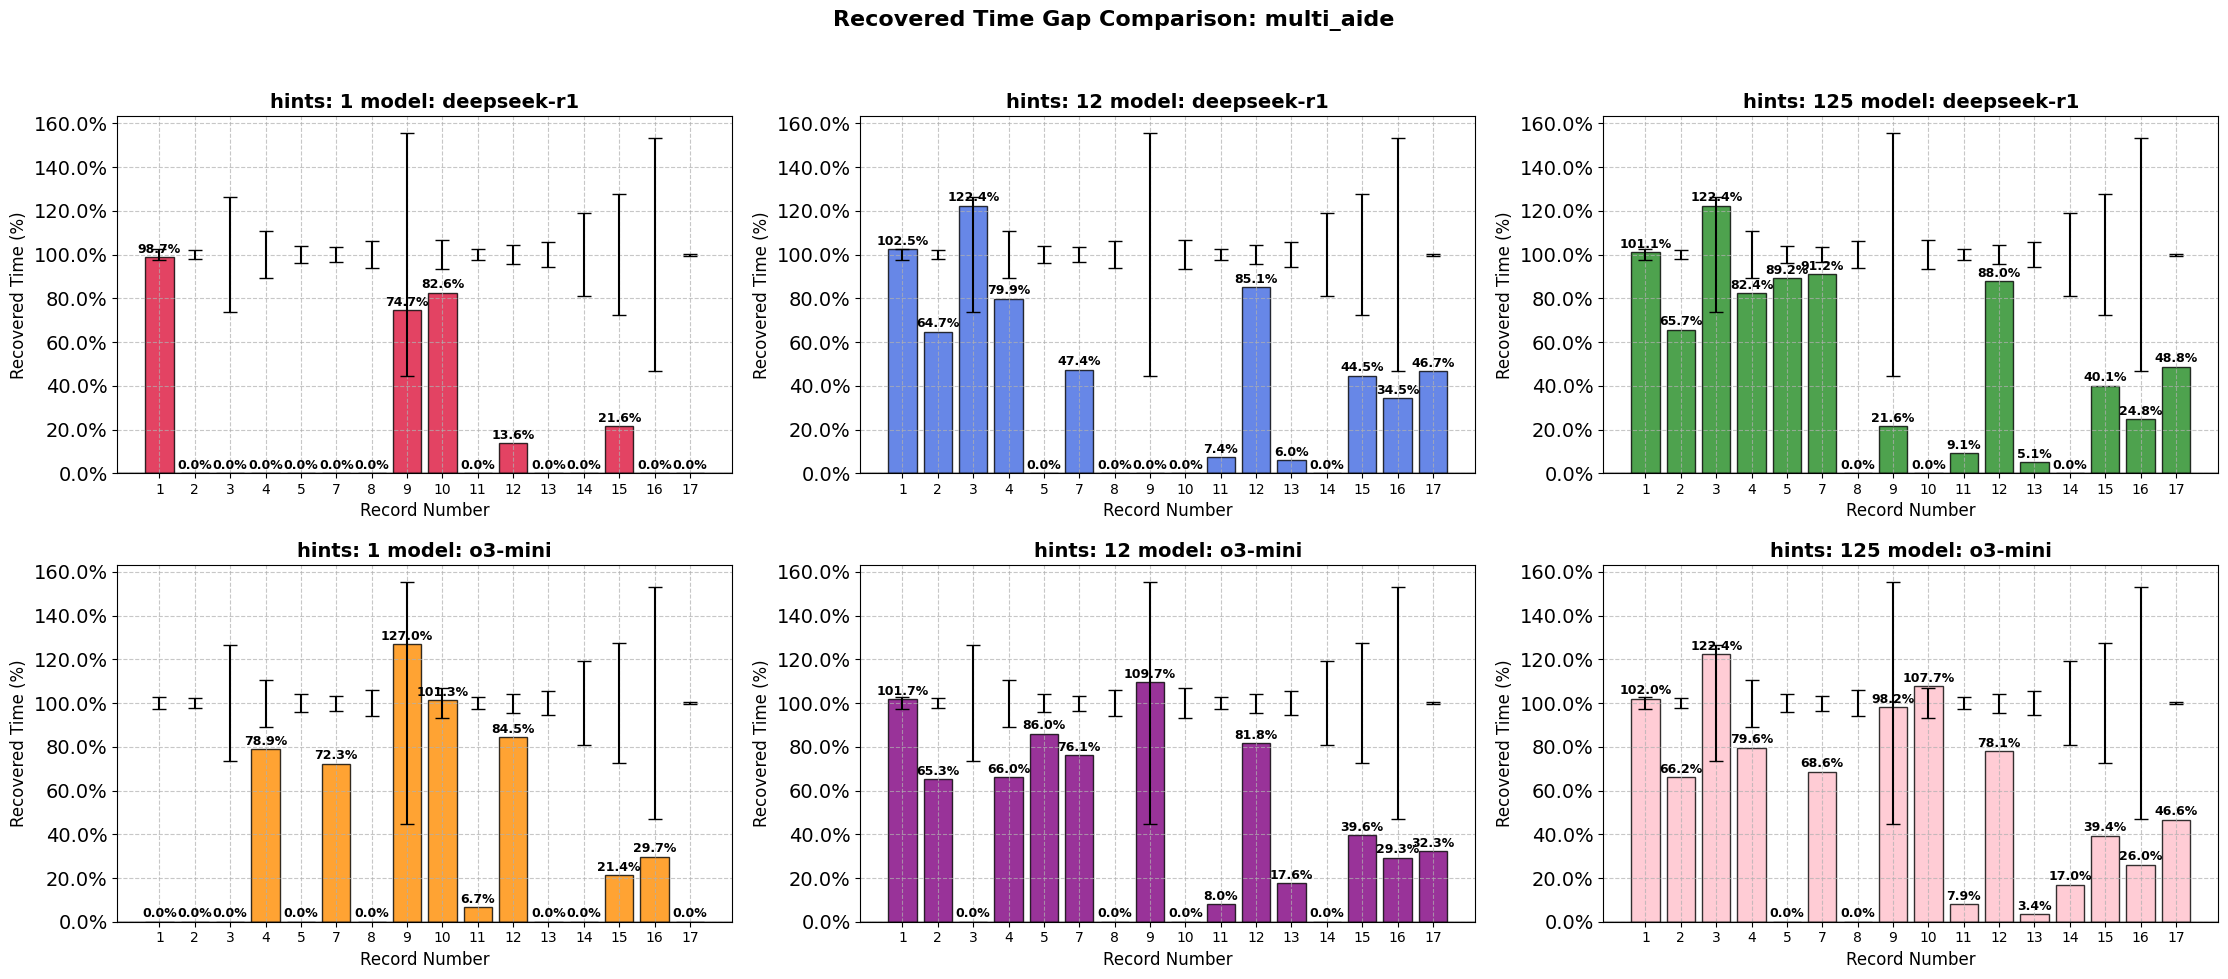

In [19]:
# get 6 colors
colors = ['crimson', 'royalblue', 'forestgreen', 'darkorange', 'purple', 'pink']
for search_algo in ['flat', 'tree', 'forest', 'aide', 'multi_aide']:
    filtered_figure_data = {k: v for k, v in figure_data.items() if search_algo in k}
    data_dicts = []
    i = 0
    for model in ('deepseek-r1', 'o3-mini'):
        for level in [1, 12, 125]:
            data_dicts.append((
                filtered_figure_data[f'{search_algo}_{level}_{model}'], 
                f'hints: {level} model: {model}', 
                colors[i]
            ))
            i += 1
    plot_gap_comparison(
        data_dicts, 
        std_dicts=std_percentage,
        figsize=(15, 10), 
        n_cols=3, 
        main_title=f'Recovered Time Gap Comparison: {search_algo}'
    )
    # plt.savefig(f'../figures/{search_algo}_placeholder.pdf', dpi=150)
    plt.show()

